<a href="https://colab.research.google.com/github/albatrani1/Pizza-vs-Not-Pizza/blob/main/Pizza_vs_Not_Pizza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#My dataset is available in googledrive; so I am accessing my drive from colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#Once this is executed, you will see your drive appearing on the left hand side

Mounted at /content/drive


In [ ]:
from google.colab import files
#
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"naeemalb","key":"d873dad66e695317cb0552468fe0cae3"}'}

In [ ]:
# Create and configure the Kaggle API directory by copying the
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download Pizza vs Not Pizza dataset from Kaggle
!kaggle datasets download -d carlosrunner/pizza-not-pizza
# Unzip the dataset
!unzip -q pizza-not-pizza.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/carlosrunner/pizza-not-pizza
License(s): other
100% 101M/101M [00:07<00:00, 14.5MB/s]



In [ ]:
import os

# Check where the dataset was extracted
for root, dirs, files in os.walk('/content'):
    if 'pizza_not_pizza' in root.lower():
        print(root)

/content/dataset/pizza_not_pizza
/content/dataset/pizza_not_pizza/pizza
/content/dataset/pizza_not_pizza/not_pizza


In [ ]:
# Define paths to the dataset
pizza_dir = "/content/dataset/pizza_not_pizza/pizza"  # Update with your actual path
not_pizza_dir = "/content/dataset/pizza_not_pizza/not_pizza"  # Update with your actual path

In [ ]:
import os

print("Pizza folder exists:", os.path.exists(pizza_dir))
print("Not Pizza folder exists:", os.path.exists(not_pizza_dir))

print("Pizza images:", len(os.listdir(pizza_dir)))
print("Not Pizza images:", len(os.listdir(not_pizza_dir)))

Pizza folder exists: True
Not Pizza folder exists: True
Pizza images: 983
Not Pizza images: 983


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/dataset/pizza_not_pizza"

# Create ImageDataGenerator for training set
train_datagen = ImageDataGenerator(
    rescale=1./255,#normalisation / feature scaling
    validation_split=0.2 # Split 20% of the images for validation
)
# Load and prepare training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary', # 'binary' for binary classification (cats vs. dogs)
    subset='training' # Specify 'training' for the training set
)

# Create ImageDataGenerator for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)
# Load and prepare validation data
validation_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    subset='validation' # Specify 'validation' for the validation set
)

Found 1574 images belonging to 2 classes.
Found 392 images belonging to 2 classes.


In [ ]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [ ]:
# create CNN model - custom-made

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten()) #converting 2D to 1 D

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))  #output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy']) #binary_crossentropy - binary classification

In [ ]:
history = model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 254ms/step - accuracy: 0.5273 - loss: 0.7220 - val_accuracy: 0.6888 - val_loss: 0.6229
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.6544 - loss: 0.6230 - val_accuracy: 0.6888 - val_loss: 0.5988
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - accuracy: 0.6804 - loss: 0.5939 - val_accuracy: 0.7500 - val_loss: 0.5526
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.7325 - loss: 0.5262 - val_accuracy: 0.7755 - val_loss: 0.5127
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.7872 - loss: 0.4696 - val_accuracy: 0.7704 - val_loss: 0.4966
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.8405 - loss: 0.3732 - val_accuracy: 0.7730 - val_loss: 0.5394
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.9003 - loss: 0.2479 - val_accuracy: 0.6454 - val_loss: 0.8804
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.9263 - loss: 0.1883 - val_accuracy: 0

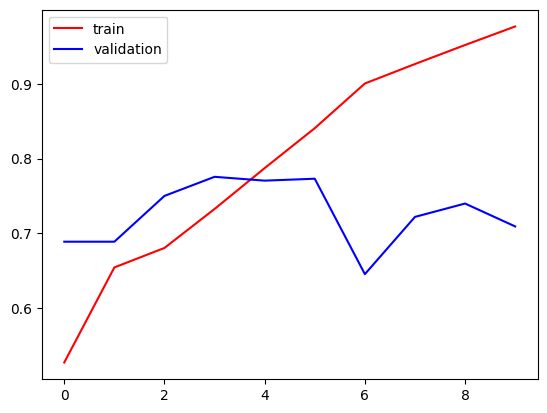

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

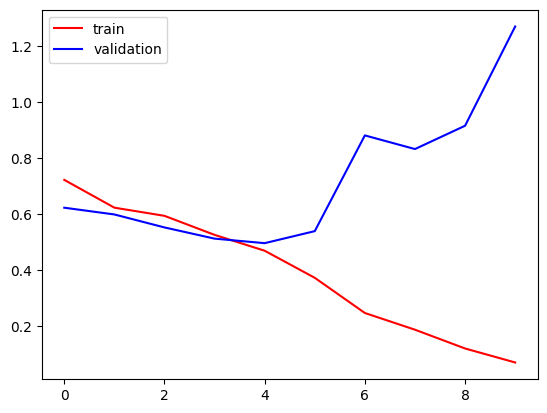

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

source_dir = "/content/dataset/pizza_not_pizza"

train_dir = "/content/pizza_split/train"
test_dir = "/content/pizza_split/test"

for cls in ["pizza", "not_pizza"]:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    files = os.listdir(os.path.join(source_dir, cls))

    train_files, test_files = train_test_split(
        files,
        test_size=0.2,
        random_state=42
    )

    for f in train_files:
        shutil.copy(
            os.path.join(source_dir, cls, f),
            os.path.join(train_dir, cls, f)
        )

    for f in test_files:
        shutil.copy(
            os.path.join(source_dir, cls, f),
            os.path.join(test_dir, cls, f)
        )

print("Done!")

Done!


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 394 images belonging to 2 classes.


In [ ]:
#predict the test data
predictions = model.predict(test_data)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[176  21]
 [  7 190]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.93       197
           1       0.90      0.96      0.93       197

    accuracy                           0.93       394
   macro avg       0.93      0.93      0.93       394
weighted avg       0.93      0.93      0.93       394



There is overfitting and hence applying Batchnormalisation and Dropout techniques to handle overfitting

In [ ]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(1,activation='sigmoid'))  #output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 222ms/step - accuracy: 0.6334 - loss: 4.5566 - val_accuracy: 0.4490 - val_loss: 5.4272
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.6677 - loss: 2.1228 - val_accuracy: 0.5102 - val_loss: 8.1092
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.7236 - loss: 1.3735 - val_accuracy: 0.5536 - val_loss: 2.0058
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.7300 - loss: 1.1428 - val_accuracy: 0.5179 - val_loss: 2.3780
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.7490 - loss: 0.9250 - val_accuracy: 0.5332 - val_loss: 0.9994
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.8113 - loss: 0.5206 - val_accuracy: 0.5995 - val_loss: 1.2180
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.8501 - loss: 0.4406 - val_accuracy: 0.6173 - val_loss: 0.8626
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.8450 - loss: 0.4157 - val_accuracy: 0

In [ ]:
# Load and preprocess test images for evaluating the trained model on unseen data                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 394 images belonging to 2 classes.


In [ ]:
predictions = model.predict(test_data)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[147  50]
 [162  35]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.48      0.75      0.58       197
           1       0.41      0.18      0.25       197

    accuracy                           0.46       394
   macro avg       0.44      0.46      0.41       394
weighted avg       0.44      0.46      0.41       394



Using Pre-trained model (Transfer learning) - Resnet50  -- 50 Convolutional layers + fully connected layer





In [ ]:
# Import required libraries for building and training the ResNet50 model
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Apply image preprocessing and data augmentation to improve model generalization
resnet_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True

)
# Load and preprocess training images from the dataset
resnet_train_data = resnet_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

# Load validation images using the validation split
resnet_validation_data = resnet_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# Load test images for final model evaluation
resnet_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

resnet_test_data = resnet_test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)
resnet_model = Sequential()    #ResNet50 is a pre-trained model
pretrained_model = tf.keras.applications.ResNet50(include_top = False, #because i have my own image of a diff dimension
                                                input_shape = (256,256,3),
                                                pooling = 'max', classes = 2,
                                                weights = 'imagenet')
for layer in pretrained_model.layers:
    layer.trainable = False  #all layers in the Resnet50 is not trainable; keep those weights; I am going to add my own i/p and other layers

# Add custom classification layers for binary image classification
resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(tf.keras.layers.Dropout(0.5))
resnet_model.add(Dense(256, activation='relu'))
resnet_model.add(tf.keras.layers.Dropout(0.3))
resnet_model.add(Dense(1, activation='sigmoid'))

Found 1258 images belonging to 2 classes.
Found 314 images belonging to 2 classes.
Found 394 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [ ]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = resnet_model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 393ms/step - accuracy: 0.5019 - loss: 1.3005 - val_accuracy: 0.5077 - val_loss: 0.7146
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.5299 - loss: 0.7445 - val_accuracy: 0.5510 - val_loss: 0.6862
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.5521 - loss: 0.6925 - val_accuracy: 0.5306 - val_loss: 0.6921
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.5464 - loss: 0.6856 - val_accuracy: 0.5459 - val_loss: 0.6778
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.5470 - loss: 0.6794 - val_accuracy: 0.5714 - val_loss: 0.6799
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.5419 - loss: 0.6835 - val_accuracy: 0.5306 - val_loss: 0.6813
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.5292 - loss: 0.6855 - val_accuracy: 0.5153 - val_loss: 0.6919
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.5553 - loss: 0.6779 - val_accuracy: 

In [ ]:
predictions = resnet_model.predict(test_data)

13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 605ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[197   0]
 [197   0]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       197
           1       0.00      0.00      0.00       197

    accuracy                           0.50       394
   macro avg       0.25      0.50      0.33       394
weighted avg       0.25      0.50      0.33       394



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
